In [1]:
from math import pi
import itertools

import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import numpy as np
import scipy.special
import scqubits as scq
import skimage
import tqdm.contrib.itertools
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.plotting.cookbook import imshow_heatmap

In [2]:
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi'] = 100
plt.style.use("fluxoniumcr.plotting.paper")

In [3]:
colors = ['C0', 'C3', 'C4', 'C1', 'C5']

In [4]:
def add_qubit(ax, x, y, index):
    radius = 5/72
    
    lw = 1
    ec = 'black'
    fc = colors[index]
    
    trans = (
        ax.figure.dpi_scale_trans +
        mpl.transforms.ScaledTranslation(x, y, ax.transData)
    )
    
    if index == 0:
        patch = mpl.patches.Circle(
            (0, 0),
            radius=radius,
            linewidth=lw,
            facecolor=fc,
            edgecolor=ec,
            zorder=100,
            transform=trans,
        )
    elif index == 1:
        patch = mpl.patches.RegularPolygon(
            (0, 0),
            4,
            radius=1.04 * radius * 4/np.pi,
            orientation=np.pi/4,
            linewidth=lw,
            facecolor=fc,
            edgecolor=ec,
            zorder=100,
            transform=trans,
        )
    elif index == 2:
        patch = mpl.patches.RegularPolygon(
            (0, 0),
            4,
            radius=radius * 4/np.pi,
            linewidth=lw,
            facecolor=fc,
            edgecolor=ec,
            zorder=100,
            transform=trans,
        )
    elif index == 3:
        ratio = 1/3
        verts = 0.91 * radius * 4/np.pi * np.array([
            [1, -ratio],
            [1, +ratio],
            [+ratio, +ratio],
            [+ratio, 1],
            [-ratio, 1],
            [-ratio, +ratio],
            [-1, +ratio],
            [-1, -ratio],
            [-ratio, -ratio],
            [-ratio, -1],
            [+ratio, -1],
            [+ratio, -ratio],
        ])
        verts @= np.array([
            [np.cos(np.pi/4), -np.sin(np.pi/4)],
            [np.sin(np.pi/4), np.cos(np.pi/4)],
        ])
        patch = mpl.patches.Polygon(
            verts,
            linewidth=lw,
            facecolor=fc,
            edgecolor=ec,
            zorder=100,
            transform=trans,
        )
#         patch = mpl.patches.RegularPolygon(
#             (0, 0),
#             6,
#             radius=radius / 0.827,
#             orientation=np.pi/4,
#             linewidth=lw,
#             facecolor=fc,
#             edgecolor=ec,
#             zorder=100,
#             transform=trans,
#         )
    else:
        angles = 1.04 * np.pi/2 + np.linspace(0, 2*np.pi, num=8, endpoint=False)
        radii = np.empty_like(angles)
        radii[::2] = radius * 4/np.pi
        radii[1::2] = radii[::2] * 0.45
        verts = np.column_stack([
            radii*np.cos(angles),
            radii*np.sin(angles),
        ])
        patch = mpl.patches.Polygon(
            verts,
            linewidth=lw,
            facecolor=fc,
            edgecolor=ec,
            zorder=100,
            transform=trans,
        )
            
    ax.add_patch(patch)

In [5]:
def plot_square_lattice(ax):
    lw = 1
    fc = colors[0]
    ec = 'black'
    radius = 4/72

    for i in range(2):
        for j in range(2):
            x = 2*j
            y = 1 + 2*i
            index = 1 + 2*(1 - i) + j
            if index == 4:
                index = 3
            elif index == 3:
                index = 4
            add_qubit(ax, x, y, index)


    for i in range(2):
        for j in range(2):
            fc = colors[0]
            x = 1 + 2*j
            y = 2*i
            index = 0
            add_qubit(ax, x, y, index)

    paths = [
        [
            [0, 3],
            [3, 0],
        ],
        [
            [0, 1],
            [2, 3],
        ],
        [
            [1, 0],
            [3, 2],
        ],
        [
            [0, 1],
            [1, 0],
        ],
        [
            [2, 3],
            [3, 2],
        ],
    ]

    for path in paths:
        ax.plot(
            *np.array(path).T,
            c='black',
        )

    paths = [
        (
            (0, 3)
            + np.array([
                [-0.5, -0.5],
                [+0.5, +0.5],
            ])
        ),
        (
            (0, 3)
            + np.array([
                [-0.5, +0.5],
                [0, 0],
            ])
        ),
        (
            (2, 3)
            + np.array([
                [-0.5, +0.5],
                [0, 0],
                [+0.5, +0.5],
            ])
        ),
        (
            (3, 2)
            + np.array([
                [+0.5, +0.5],
                [0, 0],
                [+0.5, -0.5],
            ])
        ),
        (
            (1, 0)
            + np.array([
                [-0.5, -0.5],
                [0, 0],
                [+0.5, -0.5],
            ])
        ),
        (
            (3, 0)
            + np.array([
                [+0.5, +0.5],
                [-0.5, -0.5],
            ])
        ),
        (
            (3, 0)
            + np.array([
                [+0.5, -0.5],
                [0, 0],
            ])
        ),
        (
            (0, 1)
            + np.array([
                [-0.5, +0.5],
                [0, 0],
                [-0.5, -0.5],
            ])
        ),
    ]
    for path in paths:
        ax.plot(
            *np.array(path).T,
            ls=':',
            c='black',
            clip_on=False,
        )


In [6]:
def plot_hexagon_lattice(ax):
    lw = 1
    fc = colors[0]
    ec = 'black'
    
    for i in range(3):
        for j in range(3):
            x = 2*j
            y = 1 + 2*i
            index = 1+((1+j+i)%3)
            add_qubit(ax, x, y, index)


    for i in range(3):
        for j in range(3):
            x = 1 + 2*j
            y = 2*i
            index = 0
            add_qubit(ax, x, y, index)

    vertices = np.array([
        [0, 1],
        [1, 2],
        [0, 3],
        [2, 5],
        [3, 4],
        [4, 5],
        [5, 4],
        [4, 3],
        [5, 2],
        [3, 0],
        [2, 1],
        [1, 0],
        [0, 1],
    ])
    path = mpl.path.Path(
        vertices=vertices,
        closed=True
    )
    path_patch = mpl.patches.PathPatch(
        path,
        fc='none',
        ec='black',
    )
    ax.add_patch(path_patch)

    paths = [
        [
            [0, 5],
            [1, 4],
        ],
        [
            [1, 2],
            [3, 4],
        ],
        [
            [2, 3],
            [3, 2],
        ],
        [
            [2, 1],
            [4, 3],
        ],
        [
            [4, 1],
            [5, 0],
        ],
    ]

    for path in paths:
        ax.plot(
            *np.array(path).T,
            c='black',
        )

    paths = [
        (
            (0, 5)
            + np.array([
                [-0.5, -0.5],
                [+0.5, +0.5],
            ])
        ),
        (
            (5, 0)
            + np.array([
                [-0.5, -0.5],
                [+0.5, +0.5],
            ])
        ),
        (
            (2, 3)
            + np.array([
                [+0.5, +0.5],
                [0, 0],
            ])
        ),
        (
            (4, 3)
            + np.array([
                [+0.5, +0.5],
                [0, 0],
            ])
        ),
        (
            (5, 2)
            + np.array([
                [+0.5, +0.5],
                [0, 0],
            ])
        ),
        (
            (5, 4)
            + np.array([
                [+0.5, +0.5],
                [0, 0],
            ])
        ),
        (
            (4, 5)
            + np.array([
                [+0.5, +0.5],
                [0, 0],
            ])
        ),
        (
            (2, 5)
            + np.array([
                [+0.5, +0.5],
                [0, 0],
            ])
        ),
        (
            (0, 1)
            + np.array([
                [-0.5, -0.5],
                [0, 0],
            ])
        ),
        (
            (0, 3)
            + np.array([
                [-0.5, -0.5],
                [0, 0],
            ])
        ),
        (
            (1, 0)
            + np.array([
                [-0.5, -0.5],
                [0, 0],
            ])
        ),
        (
            (3, 0)
            + np.array([
                [-0.5, -0.5],
                [0, 0],
            ])
        ),
    ]
    for path in paths:
        ax.plot(
            *np.array(path).T,
            ls=':',
            c='black',
            clip_on=False,
        )

In [7]:
def plot_heavyhex_lattice(ax):
    lw = 1
    fc = colors[0]
    ec = 'black'

    for i in range(2):
        for j in range(4):
            x = j
            y = 2*i + 1 - (j%2)
            index = 1 + ((2*i + j)%2)
            add_qubit(ax, x, y, index)


    for i in range(3):
        for j in range(3):
            if i == j == 1: continue
            x = 0.5 + j
            y = 0.5 + i
            index = 0
            add_qubit(ax, x, y, index)

    vertices = [
        [-0.5, 2.5],
        [+0.5, 3.5],
        [-0.5, 0.5],
        [2.5, 3.5],
    ]
    for x, y in vertices:
        index = 0
        add_qubit(ax, x, y, index)

    paths = [
        [
            [-0.5, 2.5],
            [+0.5, 3.5],
        ],
        [
            [0, 3],
            [1, 2],
        ],
        [
            [-0.5, +0.5],
            [2.5, 3.5],
        ],
        [
            [0, 1],
            [1, 0],
            [3, 2],
            [2, 3],
        ],
        [
            [2, 1],
            [3, 0],
        ],
    ]

    for path in paths:
        ax.plot(
            *np.array(path).T,
            c='black',
        )


    paths = [
        (
            (0.5, 3.5)
            + np.array([
                [+0.25, +0.25],
                [0, 0],
            ])
        ),
        (
            (2.5, 3.5)
            + np.array([
                [+0.25, +0.25],
                [0, 0],
            ])
        ),
        (
            (3, 2)
            + np.array([
                [+0.25, +0.25],
                [0, 0],
            ])
        ),
        (
            (3, 0)
            + np.array([
                [-0.25, -0.25],
                [0, 0],
            ])
        ),
        (
            (3, 0)
            + np.array([
                [+0.25, +0.25],
                [0, 0],
            ])
        ),
        (
            (1, 0)
            + np.array([
                [-0.25, -0.25],
                [0, 0],
            ])
        ),
        (
            (-0.5, +0.5)
            + np.array([
                [-0.25, -0.25],
                [0, 0],
            ])
        ),
        (
            (-0.5, 2.5)
            + np.array([
                [-0.25, -0.25],
                [0, 0],
            ])
        ),
    ]
    for path in paths:
        ax.plot(
            *np.array(path).T,
            ls=':',
            c='black',
            clip_on=False,
        )

    

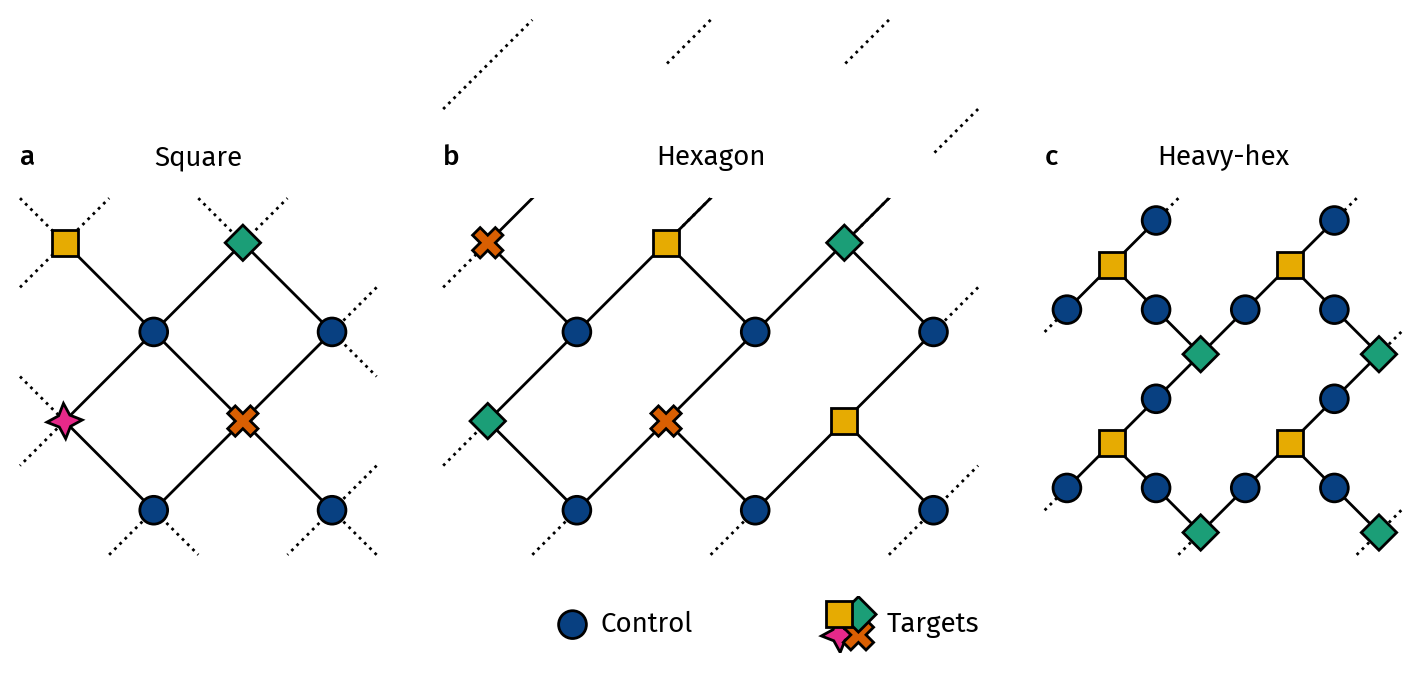

In [8]:
fig = plt.figure(
    figsize=(179/25.4, 65/25.4),
)

gs = GridSpec(
    nrows=2,
    ncols=3,
    figure=fig,
    width_ratios=[1, 1.5, 1],
    height_ratios=[1, 0.15],
    wspace=0.16,
    hspace=0.14,
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :])

plot_square_lattice(ax1)
plot_hexagon_lattice(ax2)
plot_heavyhex_lattice(ax3)

for ax in (ax1, ax2, ax3, ax4):
    ax.set_axis_off()

ax1.set_xlim(-0.5, 3.5)
ax1.set_ylim(-0.5, 3.5)
ax1.set_aspect(1)

ax2.set_xlim(-1, 6)
ax2.set_ylim(-2, 5)
ax2.set_xlim(-0.5, 5.5)
ax2.set_ylim(-0.5, 3.5)
ax2.set_aspect(1)

ax3.set_xlim(-0.75, 3.25)
ax3.set_ylim(-0.25, 3.75)
ax3.set_aspect(1)

for ax, subfig_label, text in [
    (ax1, "a", "Square"),
    (ax2, "b", "Hexagon"),
    (ax3, "c", "Heavy-hex"),
]:
    ax.annotate(
        subfig_label,
        (0.0, 1),
        xytext=(0, 10),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha='left',
        va='bottom',
    )
    ax.annotate(
        text,
        (0.5, 1),
        xytext=(0, 10),
        xycoords='axes fraction',
        textcoords='offset points',
        fontsize=10,
        ha='center',
        va='bottom',
    )
    
fig.subplots_adjust(
    wspace=0.2,
    hspace=0,
)

xoff = 0.2
add_qubit(
    ax4,
    x=-xoff,
    y=0,
    index=0,
)
ax4.annotate(
    "Control",
    (-xoff, 0),
    xytext=(10, 0),
    textcoords='offset points',
    fontsize=10,
    ha='left',
    va='center',
)

xgap = 0.014
ygap = 0.18
add_qubit(
    ax4,
    x=xoff - xgap,
    y=-ygap,
    index=4,
)
add_qubit(
    ax4,
    x=xoff + xgap,
    y=-ygap,
    index=3,
)
add_qubit(
    ax4,
    x=xoff + xgap,
    y=ygap,
    index=2,
)
add_qubit(
    ax4,
    x=xoff - xgap,
    y=ygap,
    index=1,
)
ax4.annotate(
    "Targets",
    (xoff + xgap, 0),
    xytext=(10, 0),
    textcoords='offset points',
    fontsize=10,
    ha='left',
    va='center',
)

ax4.set_xlim(-1, 1)
ax4.set_ylim(-0.5, 0.5)

# ax4.set_axis_on()
# ax4.set_facecolor('red')
fig.subplots_adjust(
    left=0.01,
    bottom=0,
    right=0.99,
    top=0.91,
)
fig.savefig("connectivity.pdf")

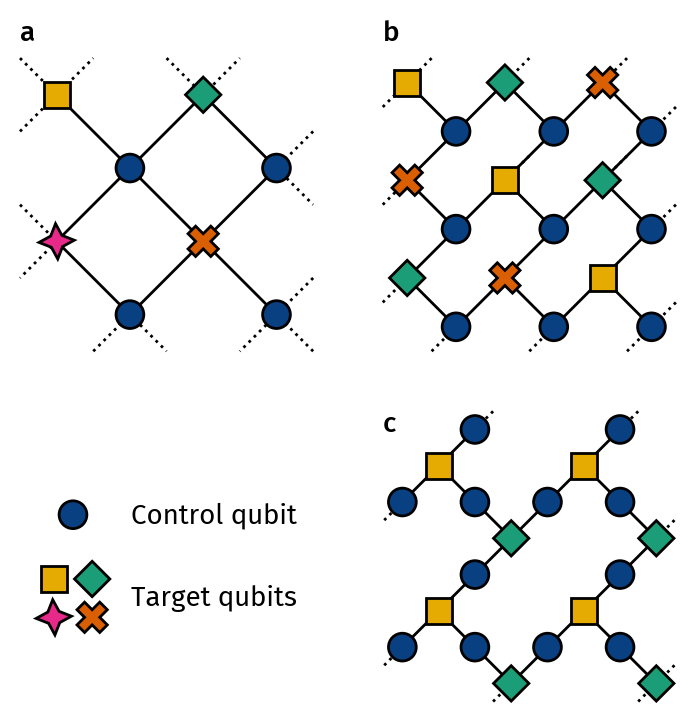

In [23]:
fig = plt.figure(
    figsize=(85/25.4, 90/25.4),
)

gs = GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[1, 1],
    height_ratios=[1, 1],
    wspace=0.2,
    hspace=0.2,
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 0])

ax1.set_anchor("SW")
ax2.set_anchor("SE")
ax3.set_anchor("NE")
ax4.set_anchor("NW")

plot_square_lattice(ax1)
plot_hexagon_lattice(ax2)
plot_heavyhex_lattice(ax3)

for ax in (ax1, ax2, ax3, ax4):
    ax.set_axis_off()

ax1.set_xlim(-0.5, 3.5)
ax1.set_ylim(-0.5, 3.5)
ax1.set_aspect(1)

ax2.set_xlim(-0.5, 5.5)
ax2.set_ylim(-0.5, 5.5)
ax2.set_aspect(1)

ax3.set_xlim(-0.77, 3.27)
ax3.set_ylim(-0.27, 3.77)
ax3.set_aspect(1)

for ax, subfig_label, text, xytext in [
    (ax1, "a", "Square", (0, 14)),
    (ax2, "b", "Hexagon", (0, 14)),
    (ax3, "c", "Heavy-hex", (0, 0)),
]:
    ax.annotate(
        subfig_label,
        (0.0, 1),
        xytext=xytext,
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha='left',
        va='top',
    )
#     ax.annotate(
#         text,
#         (0.5, 1),
#         xytext=(0, 10),
#         xycoords='axes fraction',
#         textcoords='offset points',
#         fontsize=10,
#         ha='center',
#         va='bottom',
#     )

xoff = 0.53
yoff = 0.37
xgap = 0.17
ygap = 0.17

add_qubit(
    ax4,
    x=-xoff,
    y=yoff,
    index=0,
)
ax4.annotate(
    "Control qubit",
    (-xoff + xgap, yoff),
    xytext=(14, 0),
    textcoords='offset points',
    fontsize=10,
    ha='left',
    va='center',
)

add_qubit(
    ax4,
    x=-xoff - xgap,
    y=-yoff - ygap,
    index=4,
)
add_qubit(
    ax4,
    x=-xoff + xgap,
    y=-yoff + ygap,
    index=2,
)
add_qubit(
    ax4,
    x=-xoff + xgap,
    y=-yoff - ygap,
    index=3,
)
add_qubit(
    ax4,
    x=-xoff - xgap,
    y=-yoff + ygap,
    index=1,
)
ax4.annotate(
    "Target qubits",
    (-xoff + xgap, -yoff),
    xytext=(14, 0),
    textcoords='offset points',
    fontsize=10,
    ha='left',
    va='center',
)

ax4.set_xlim(-1, 1)
ax4.set_ylim(-1.3, 1.3)

# ax4.set_axis_on()
# ax4.set_facecolor('red')
ax4.set_aspect(1)

fig.subplots_adjust(
    left=0.01,
    bottom=0.02,
    right=0.99,
    top=0.93,
)
fig.savefig("connectivity.pdf")